In [74]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import random
from matplotlib.animation import FuncAnimation

import numpy as np

from scipy.stats import norm

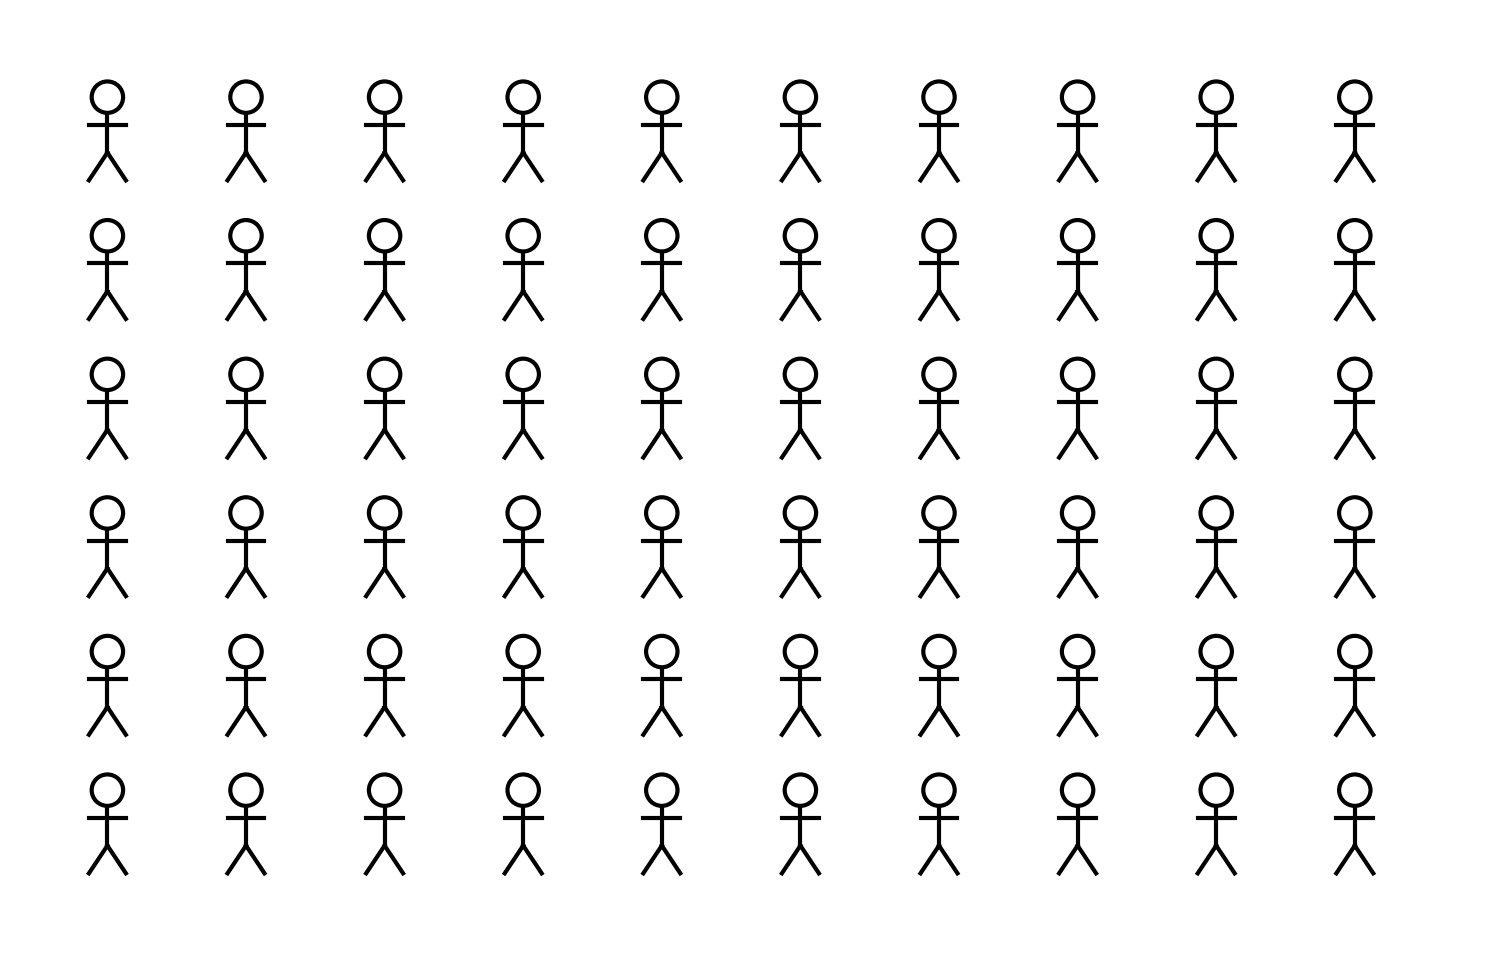

In [28]:
x_pos = 10
y_pos = 6

sample = 10

# --- Stick figure drawing function ---
def draw_stick_figure(ax, x, y, color="black"):
    """Draw a stick figure centered at (x,y)."""
    head_radius = 0.17
    # head
    ax.add_patch(plt.Circle((x, y+0.6), head_radius, fill=False, color=color, lw=2))
    # body
    ax.plot([x, x], [y, y+0.4], color=color, lw=2)
    # arms
    ax.plot([x-0.2, x+0.2], [y+0.3, y+0.3], color=color, lw=2)
    # legs
    ax.plot([x, x-0.2], [y, y-0.3], color=color, lw=2)
    ax.plot([x, x+0.2], [y, y-0.3], color=color, lw=2)

# --- Grid of positions (10 x 10) with spacing ---
spacing = 1.5  # increase to spread out figures
positions = [(i*spacing, j*spacing) for j in range(y_pos) for i in range(x_pos)]
N = len(positions)

# --- Animation setup ---
fig, ax = plt.subplots(figsize=(14, 8), dpi=150)
ax.set_aspect("equal")
ax.set_xlim(-1, x_pos*spacing)
ax.set_ylim(-1, y_pos*spacing)
ax.axis("off")

# number of frames per phase
black_frames = 8   # ~2 seconds if interval=300 ms
highlight_frames = 3
back_to_black_frames = 8
cycle_length = black_frames + highlight_frames + back_to_black_frames

# store the current highlighted set
current_highlighted = []

def random_update(frame):
    global current_highlighted
    phase = frame % cycle_length
    
    ax.clear()
    ax.set_aspect("equal")
    ax.set_xlim(-1, x_pos*spacing)
    ax.set_ylim(-1, y_pos*spacing)
    ax.axis("off")
    
    # pick new sample only at the start of the highlight phase
    if phase == black_frames:
        current_highlighted = random.sample(range(N), sample)
    elif phase >= black_frames + highlight_frames:
        current_highlighted = []  # back to full black grid
    
    for idx, (x, y) in enumerate(positions):
        if idx in current_highlighted:
            draw_stick_figure(ax, x, y, color="#e16fca")
        else:
            draw_stick_figure(ax, x, y, color="black")
    return []

fig.patch.set_alpha(0)       # figure background
ax.set_facecolor("none")     # axes background

ani = animation.FuncAnimation(
    fig, random_update, frames=300, interval=500, blit=False, repeat=True
)

ani.save("L2_images/stickfigures.gif", writer="pillow", fps=2, savefig_kwargs={"transparent": True})

In [29]:
def biased_update(frame):
    global current_highlighted
    phase = frame % cycle_length
    
    ax.clear()
    ax.set_aspect("equal")
    ax.set_xlim(-1, x_pos*spacing)
    ax.set_ylim(-1, y_pos*spacing)
    ax.axis("off")
    
    # top row indices
    top_row_indices = list(range(10))  # 0 to 9
    
    # pick new sample only at the start of the highlight phase
    if phase == black_frames:
        current_highlighted = random.sample(top_row_indices, 10)  # highlight all in top row
    elif phase >= black_frames + highlight_frames:
        current_highlighted = []  # back to full black grid
    
    for idx, (x, y) in enumerate(positions):
        if idx in current_highlighted:
            draw_stick_figure(ax, x, y, color="#e16fca")
        else:
            draw_stick_figure(ax, x, y, color="black")
    return []

fig.patch.set_alpha(0)       # figure background
ax.set_facecolor("none")     # axes background

ani = animation.FuncAnimation(
    fig, biased_update, frames=300, interval=500, blit=False, repeat=True
)

ani.save("L2_images/stickfigures_biased.gif", writer="pillow", fps=2, savefig_kwargs={"transparent": True})

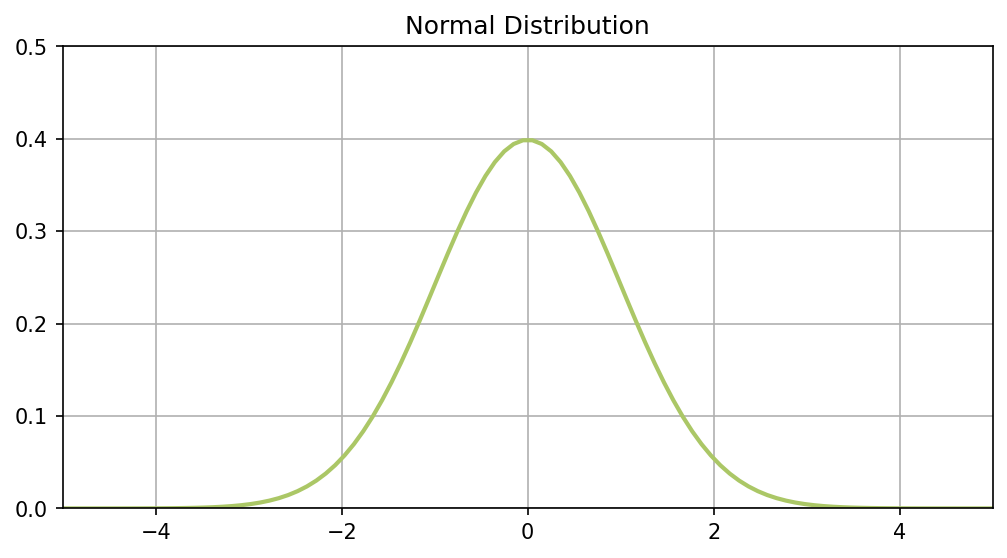

In [35]:
# plot a normal distribution in colour #abc766
x = np.linspace(-5, 5, 100)
y = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x**2)

plt.figure(figsize=(8, 4), dpi=150)
plt.plot(x, y, color="#abc766", lw=2)
plt.title('Normal Distribution')
# plt.xlabel('Z-score')
# plt.ylabel('Probability Density')
plt.grid(True)

plt.xlim(-5, 5)
plt.ylim(0, 0.5)

plt.savefig("L2_images/normal_distribution.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

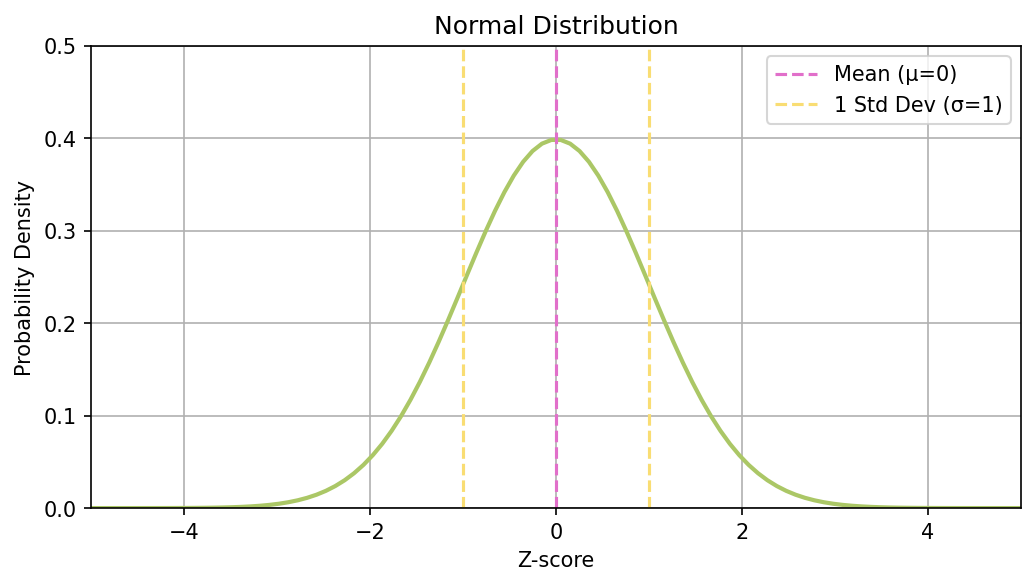

In [36]:
# plot a normal distribution in colour #abc766 - with lines showing the mean and standard deviation 
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-5, 5, 100)
y = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x**2)

plt.figure(figsize=(8, 4), dpi=150)
plt.plot(x, y, color="#abc766", lw=2)
plt.title('Normal Distribution')
plt.xlabel('Z-score')
plt.ylabel('Probability Density')
plt.grid(True)

# add mean and standard deviation lines
mean = 0
std_dev = 1
plt.axvline(mean, color="#e16fca", linestyle='--', label='Mean (μ=0)')
plt.axvline(mean + std_dev, color="#f9dd73", linestyle='--', label='1 Std Dev (σ=1)')
plt.axvline(mean - std_dev, color="#f9dd73", linestyle='--')
plt.legend()
plt.xlim(-5, 5)
plt.ylim(0, 0.5)

plt.savefig("L2_images/normal_distribution_annotated.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

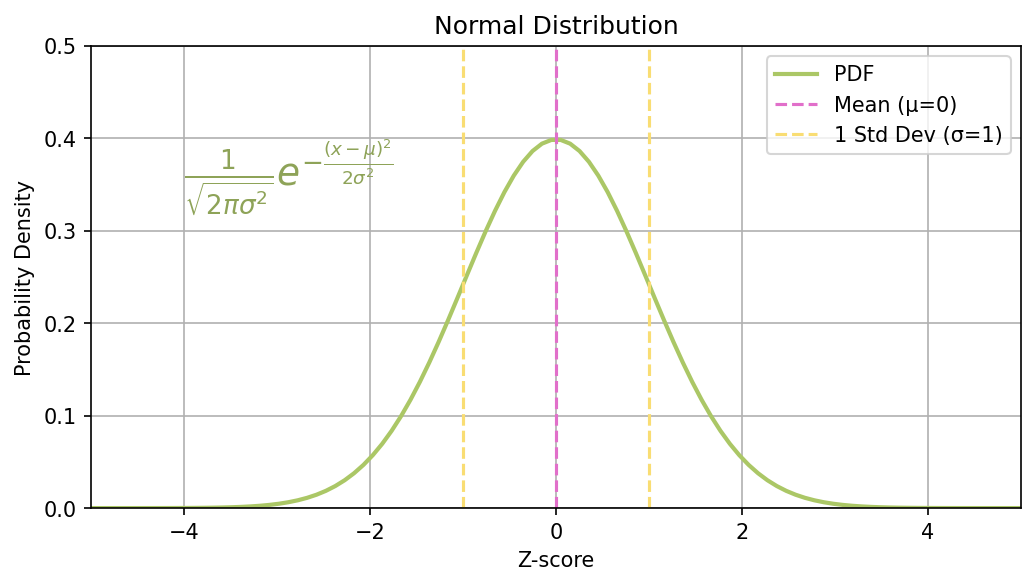

In [64]:
# plot a normal distribution in colour #abc766 - with lines showing the mean and standard deviation 
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-5, 5, 100)
y = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x**2)

plt.figure(figsize=(8, 4), dpi=150)
plt.plot(x, y, color="#abc766", lw=2, label='PDF')
plt.title('Normal Distribution')
plt.xlabel('Z-score')
plt.ylabel('Probability Density')
plt.grid(True)

# add mean and standard deviation lines
mean = 0
std_dev = 1
plt.axvline(mean, color="#e16fca", linestyle='--', label='Mean (μ=0)')
plt.axvline(mean + std_dev, color="#f9dd73", linestyle='--', label='1 Std Dev (σ=1)')
plt.axvline(mean - std_dev, color="#f9dd73", linestyle='--')
plt.legend()
plt.xlim(-5, 5)
plt.ylim(0, 0.5)

# write the pdf \frac{1}{\sqrt{2 \pi \sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}} on the plot
plt.text(-4, 0.35, r"$\frac{1}{\sqrt{2 \pi \sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$", fontsize=18, fontweight="bold", color="#8EA358")

plt.savefig("L2_images/normal_distribution_pdf.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

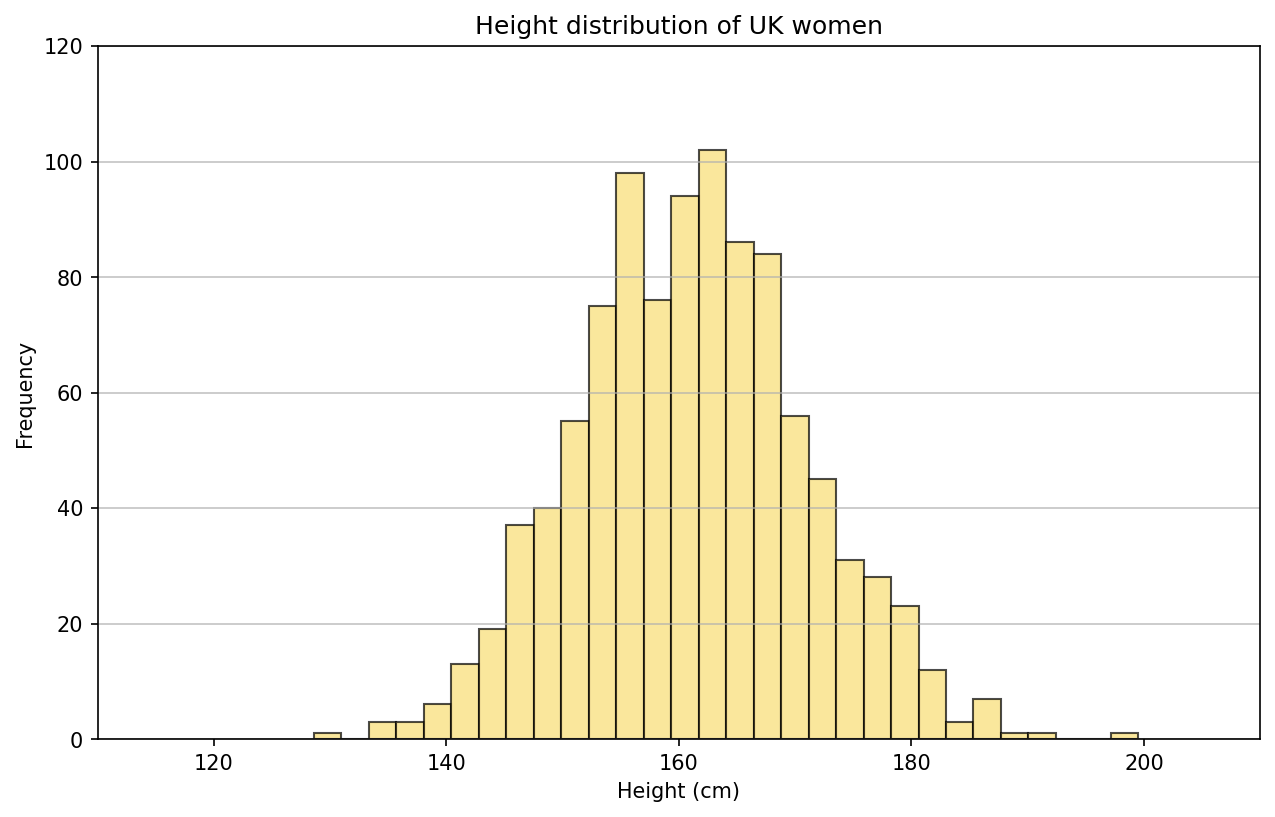

In [69]:
# generate a histogram of a normal distribution of human height in cm 

np.random.seed(42)  # for reproducibility
heights = np.random.normal(loc=161, scale=10, size=1000)
plt.figure(figsize=(10, 6), dpi=150)
plt.hist(heights, bins=30, color="#f9dd73", edgecolor="black", alpha=0.7)
plt.title('Height distribution of UK women')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.xlim(110, 210)
plt.ylim(0, 120)
plt.savefig("L2_images/height_histogram.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

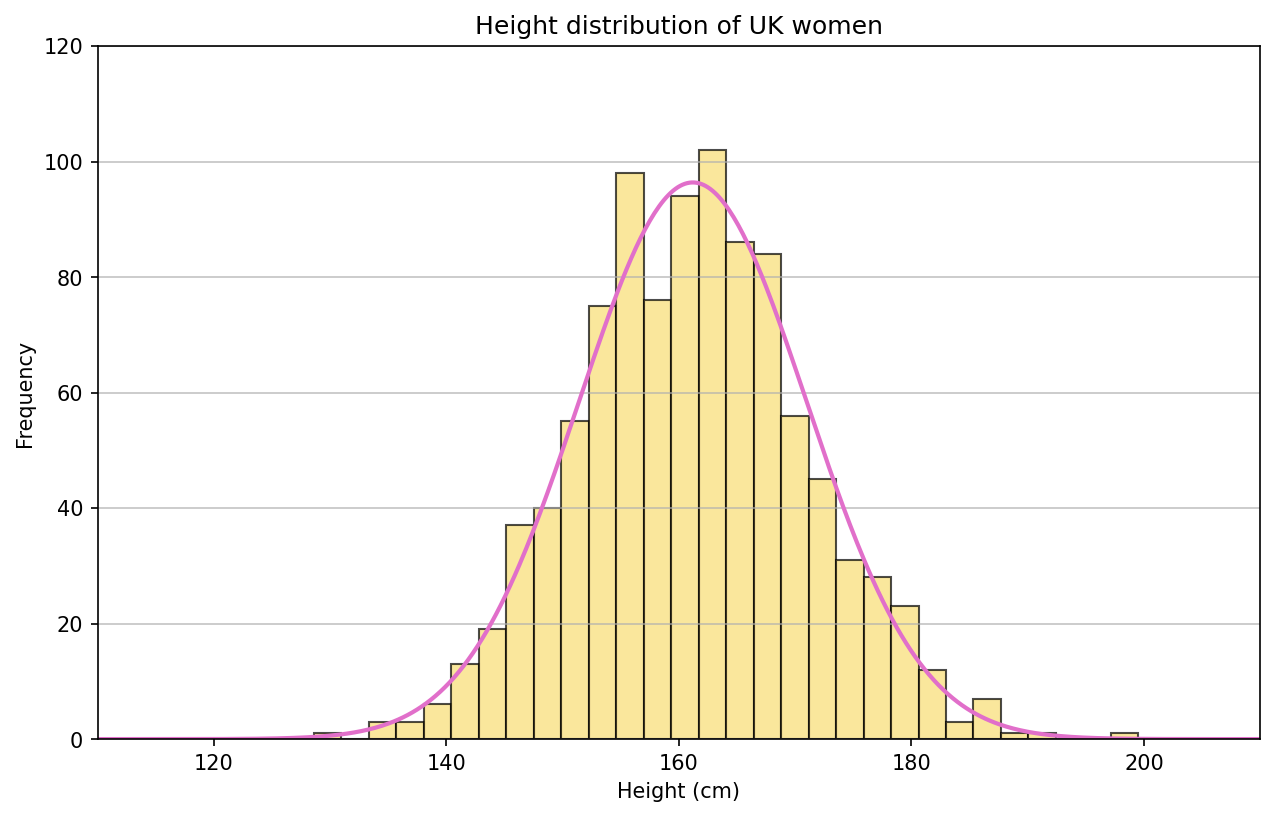

In [70]:
np.random.seed(42)
heights = np.random.normal(loc=161, scale=10, size=1000)

# Histogram parameters
bins = 30
hist_values, bin_edges = np.histogram(heights, bins=bins)

bin_width = bin_edges[1] - bin_edges[0]

plt.figure(figsize=(10, 6), dpi=150)

# Plot histogram
plt.hist(heights, bins=bins, color="#f9dd73", edgecolor="black", alpha=0.7)

# Compute Gaussian PDF scaled to histogram
mu = np.mean(heights)
sigma = np.std(heights)
x_vals = np.linspace(110, 210, 500)
pdf = norm.pdf(x_vals, mu, sigma) * len(heights) * bin_width

# Plot PDF
plt.plot(x_vals, pdf, color="#e16fca", linewidth=2)

plt.title("Height distribution of UK women")
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.xlim(110, 210)
plt.ylim(0, 120)
plt.savefig("L2_images/height_histogram_pdf.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()


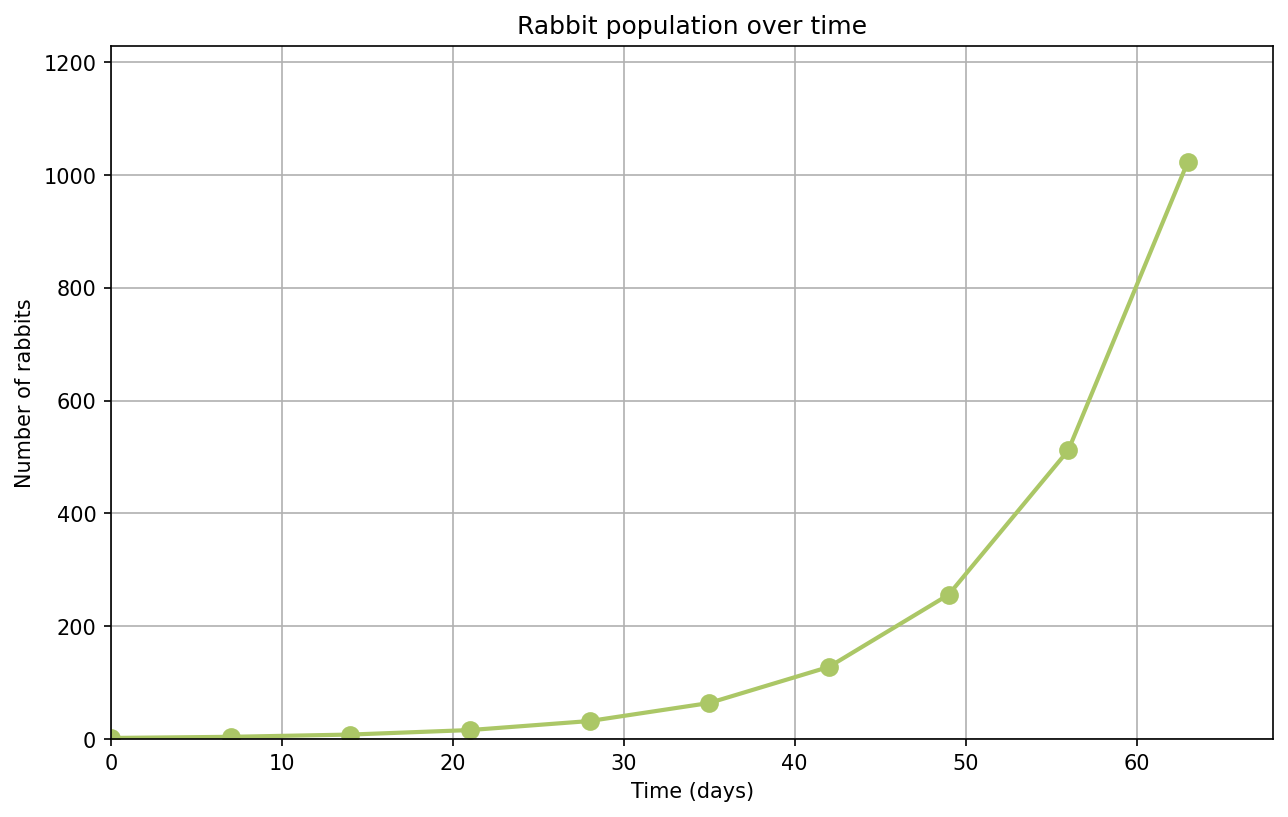

In [76]:
# Parameters
N0 = 2         # initial number of rabbits
doubling_days = 7
num_points = 10  # number of points to show

# Generate discrete time points (every 7 days)
t_points = np.arange(0, doubling_days * num_points, doubling_days)
N_points = N0 * 2**(t_points // doubling_days)

# Set up figure
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
line, = ax.plot([], [], 'o-', color="#abc766", linewidth=2, markersize=8)
ax.set_xlim(0, t_points[-1] + 5)
ax.set_ylim(0, N_points[-1] * 1.2)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Number of rabbits")
ax.set_title("Rabbit population over time")
ax.grid(True)

# Animation update function
def update(frame):
    # Show points up to current frame
    x_data = t_points[:frame + 1]
    y_data = N_points[:frame + 1]
    line.set_data(x_data, y_data)
    return line,

# Create animation
ani = FuncAnimation(fig, update, frames=len(t_points), interval=500, blit=True, repeat=True)

# To save as GIF
ani.save("L2_images/discrete_exponential.gif", writer="pillow")

plt.show()

